- `nn.Module`
- Activation functions
- Batching

# Artificial Neurons

At the core of deep learning are neural networks: models that represent complicated functions by composing simpler functions.

The basic building block is the artificial neuron. A neuron applies a _linear transformation_ to the input, then passes the result through a _non-linear activation function_. The learned parameters are the weight `w` and bias `b`.

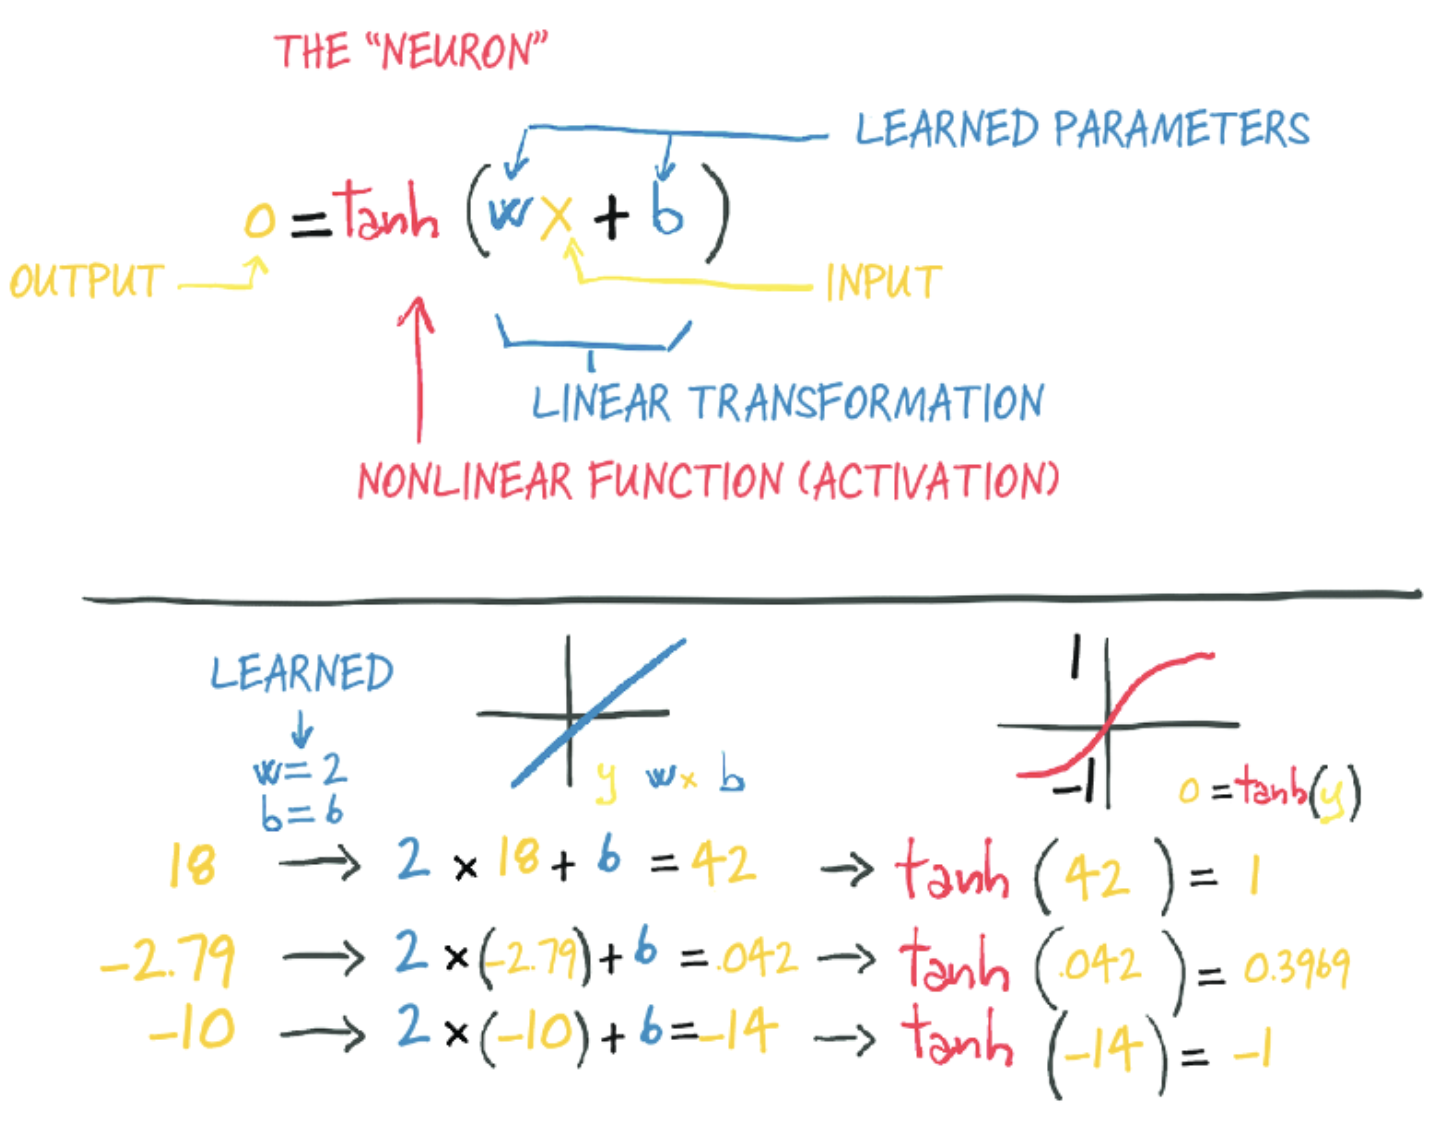


Linear models trained with squared-error loss often have a convex loss surface, which means there is one clear global minimum.

Neural networks are different. Even with the same loss function, stacking linear layers with non-linear activation functions creates a complex, non-convex loss surface.

This means there is usually no single obvious "right" setting for each parameter. Gradient descent may find a good local minimum rather than the global minimum, and in practice that is often good enough.

Combining linear transformations with non-linear activation functions gives neural networks their expressive power.

This is the intuition behind the Universal Approximation Theorem: a neural network with enough capacity can approximate many continuous nonlinear functions to arbitrary precision.

Useful intuition: by composing simple activation outputs, the network can build much more complex nonlinear shapes.

Building models from stacks of linear transformations followed by differentiable activations gives us models that can represent highly nonlinear processes while still being trainable with gradient descent.

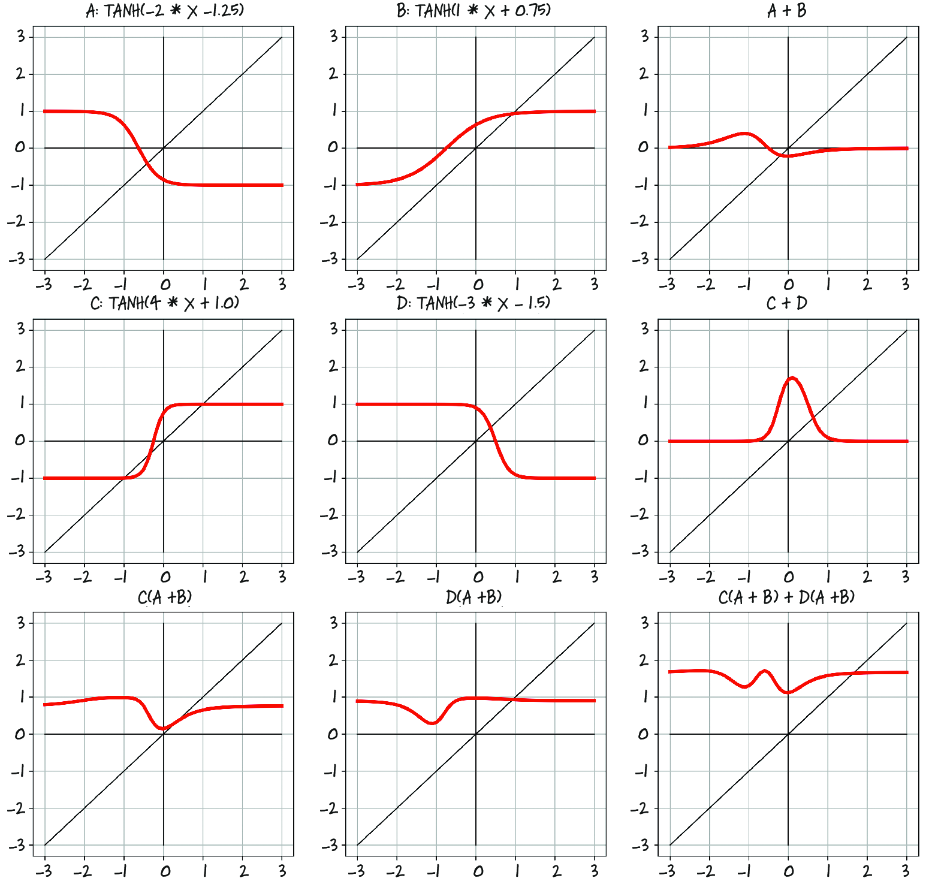


PyTorch provides many activation functions. Most of them share two important regions:

- **Sensitive range:** changes in the input produce meaningful changes in the output. This is important for learning because gradients can flow through this region.
- **Saturated range:** changes in the input produce little or no change in the output. Gradients are weaker here, so learning can slow down.

From backpropagation, this means errors propagate more effectively when activations stay in their sensitive range.

The job of a physicist or an applied mathematician is often to come up with a functional description of a phenomenon from first principles, so that we can estimate the unknown parameters from measurements and get an accurate model of the world.

Deep neural networks, on the other hand, are families of functions that have the ability to approximate a wide range of input/output relationships without necessarily requiring us to come up with an explanatory model of a phenomenon. In a way, we’re renouncing an explanation in exchange for the possibility of tackling increasingly complicated problems. In another way, we sometimes lack the ability, information, or computational resources to build an explicit model of what we’re presented with, so data-driven methods are our only way forward.

# `nn` Module

PyTorch groups most neural-network building blocks under `torch.nn`. These building blocks are called modules, and most models are either an `nn.Module` or a composition of modules.

Key ideas:

- A module is a Python class that inherits from `nn.Module`.
- Modules can own learnable tensors called `nn.Parameter`.
- Modules can contain other modules, which lets us build networks by composition.
- If I store multiple submodules in a collection, I should use `nn.ModuleList` or `nn.ModuleDict` so PyTorch can discover their parameters.

Examples: `nn.Linear` and `nn.ReLU`.

In [1]:
import torch
import torch.nn as nn

In [2]:
linear_model_1 = nn.Linear(1, 1)  # Linear(num_input_features, num_output_features, include_bias = True)
print(linear_model_1)

Linear(in_features=1, out_features=1, bias=True)


In [3]:
linear_model_2 = nn.Linear(3, 1)
print(linear_model_2)

Linear(in_features=3, out_features=1, bias=True)


In [4]:
t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
# To accommodate multiple samples, modules expect the zeroth dimension of the input to be the number of samples in the batch.
# We are doing a small hack here and add extra dimension for a sample size of 1.
t_c = torch.tensor(t_c).unsqueeze(1) # <1>
t_u = torch.tensor(t_u).unsqueeze(1) # <1>

t_u.shape

torch.Size([11, 1])

In [5]:
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_indices, val_indices

(tensor([10,  7,  2,  1,  0,  5,  4,  8,  6]), tensor([3, 9]))

In [6]:
t_u_train = t_u[train_indices]
t_c_train = t_c[train_indices]

t_u_val = t_u[val_indices]
t_c_val = t_c[val_indices]

t_un_train = 0.1 * t_u_train
t_un_val = 0.1 * t_u_val

In [7]:
t_un_val  # Only two samples in the validation set

tensor([[8.1900],
        [6.0400]])

When an `nn.Module` instance is called, PyTorch routes the call through `__call__`, which then invokes `forward` with the same arguments.

I normally define `forward`; PyTorch handles the wrapper around it. That wrapper matters because it runs hooks and other bookkeeping before and after the forward computation.

In [8]:
linear_model_1(t_un_val)

tensor([[0.6550],
        [0.3014]], grad_fn=<AddmmBackward0>)

In [9]:
linear_model_1.weight, linear_model_1.bias 

(Parameter containing:
 tensor([[0.1644]], requires_grad=True),
 Parameter containing:
 tensor([-0.6918], requires_grad=True))

Example: the module can be called directly with an input tensor.

In [10]:
x = torch.ones(1)

In [11]:
linear_model_1(x)

tensor([-0.5274], grad_fn=<ViewBackward0>)

## Batching Input

Modules in `nn` are designed to process a batch of inputs at once.

For `nn.Linear`, the input shape is usually $B \times N_{in}$:

- $B$ is the batch size.
- $N_{in}$ is the number of input features.

Example: a batch of 10 samples with 1 feature has shape `(10, 1)`.

In [12]:
x = torch.ones(10, 1)

In [13]:
x

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]])

In [14]:
linear_model_1(x)

tensor([[-0.5274],
        [-0.5274],
        [-0.5274],
        [-0.5274],
        [-0.5274],
        [-0.5274],
        [-0.5274],
        [-0.5274],
        [-0.5274],
        [-0.5274]], grad_fn=<AddmmBackward0>)

Batching is useful because it lets GPUs do more work in parallel. It is also part of how some models behave: a few layers and methods compute statistics across a batch during or around the forward pass.

Those details are beyond these notes, but the main point is that the batch dimension is not just a convenience.

In [15]:
import torch.optim as optim

In [16]:
optimizer = optim.SGD(
    linear_model_1.parameters(),
    lr=1e-2)

In [17]:
list(linear_model_1.parameters())

[Parameter containing:
 tensor([[0.1644]], requires_grad=True),
 Parameter containing:
 tensor([-0.6918], requires_grad=True)]

`nn.Parameter` is a `Tensor` subclass that `nn.Module` recognizes as learnable state.

Parameters require gradients by default because they are the values optimized by gradient descent. After `training_loss.backward()`, gradients accumulate on the leaf nodes of the computation graph. For a model, those leaf nodes are usually the parameters passed to the optimizer.

At this point, the SGD optimizer has references to the model parameters. When `optimizer.step()` is called, it loops over each `Parameter` and updates it using the value stored in its `.grad` attribute.

In [18]:
def training_loop(n_epochs, optimizer, model, loss_fn, t_u_train, t_u_val,
                  t_c_train, t_c_val):
    for epoch in range(1, n_epochs + 1):
        t_p_train = model(t_u_train)
        loss_train = loss_fn(t_p_train, t_c_train)

        t_p_val = model(t_u_val)                     
        loss_val = loss_fn(t_p_val, t_c_val)

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                  f" Validation loss {loss_val.item():.4f}")

In [19]:
training_loop(
    n_epochs = 3000,
    optimizer = optimizer,
    model = linear_model_1,
    loss_fn = nn.MSELoss(),  # Mean Square Error - We are no longer using our handwritten loss function from earlier.
    t_u_train = t_un_train,
    t_u_val = t_un_val,
    t_c_train = t_c_train,
    t_c_val = t_c_val)

Epoch 1, Training loss 118.4801, Validation loss 454.5030
Epoch 1000, Training loss 3.9191, Validation loss 8.4668
Epoch 2000, Training loss 2.9048, Validation loss 4.1300
Epoch 3000, Training loss 2.8521, Validation loss 3.5927


In [20]:
list(linear_model_1.parameters())

[Parameter containing:
 tensor([[5.2179]], requires_grad=True),
 Parameter containing:
 tensor([-16.4929], requires_grad=True)]

# Neural Network

Now I can replace the simple linear model with a small neural network by adding a non-linear hidden layer.

The important change is the activation function. Without it, stacked linear layers would still collapse into one linear transformation. With `nn.Tanh()` between the layers, the model can represent nonlinear relationships.

In [21]:
seq_model = nn.Sequential(
            nn.Linear(1, 13),
            nn.Tanh(),
            nn.Linear(13, 1))

In [22]:
seq_model

Sequential(
  (0): Linear(in_features=1, out_features=13, bias=True)
  (1): Tanh()
  (2): Linear(in_features=13, out_features=1, bias=True)
)

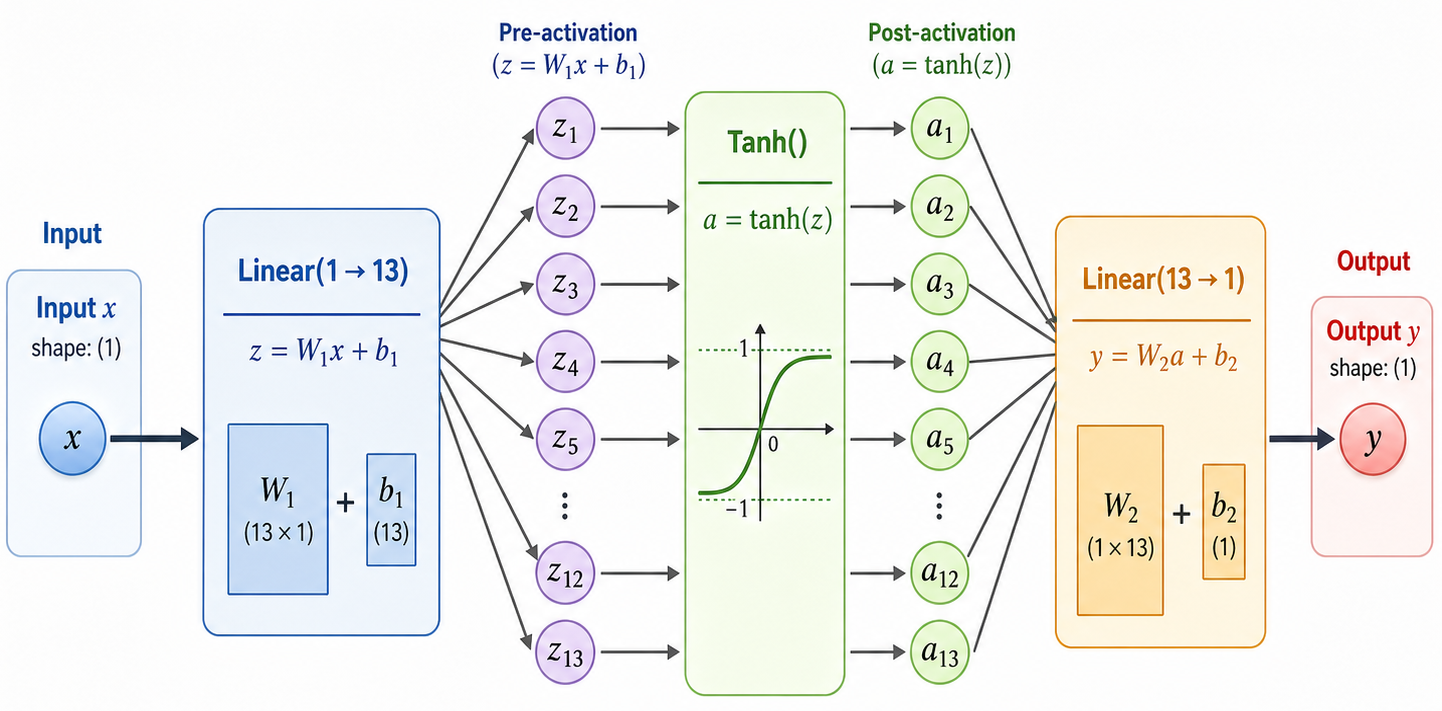


In [23]:
[param.shape for param in seq_model.parameters()]

[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 13]), torch.Size([1])]

These are the tensors the optimizer will update: the weights and biases from both `nn.Linear` layers.

In [24]:
# We can access any weights and biases we want
print(seq_model[0].bias)
print(list(seq_model[2].parameters()))

Parameter containing:
tensor([-0.6551,  0.6985,  0.4904, -0.9228,  0.1430,  0.9025, -0.7510,  0.0886,
         0.4054, -0.7504, -0.9713,  0.1170,  0.0270], requires_grad=True)
[Parameter containing:
tensor([[ 0.2075,  0.1460,  0.2476,  0.1190, -0.1028,  0.1958,  0.0526,  0.1191,
         -0.0215,  0.1709,  0.0175, -0.1322,  0.1285]], requires_grad=True), Parameter containing:
tensor([0.1564], requires_grad=True)]


In [25]:
optimizer = optim.SGD(seq_model.parameters(), lr=1e-3)

In [26]:
training_loop(
    n_epochs = 5000,
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    t_u_train = t_un_train,
    t_u_val = t_un_val,
    t_c_train = t_c_train,
    t_c_val = t_c_val)

print('output', seq_model(t_un_val))
print('answer', t_c_val)

Epoch 1, Training loss 127.9927, Validation loss 486.4229
Epoch 1000, Training loss 4.1934, Validation loss 39.9329
Epoch 2000, Training loss 2.3768, Validation loss 17.5517
Epoch 3000, Training loss 1.9569, Validation loss 11.1615
Epoch 4000, Training loss 1.8004, Validation loss 8.4019
Epoch 5000, Training loss 1.7303, Validation loss 7.0346
output tensor([[25.4271],
        [15.7290]], grad_fn=<AddmmBackward0>)
answer tensor([[28.],
        [13.]])


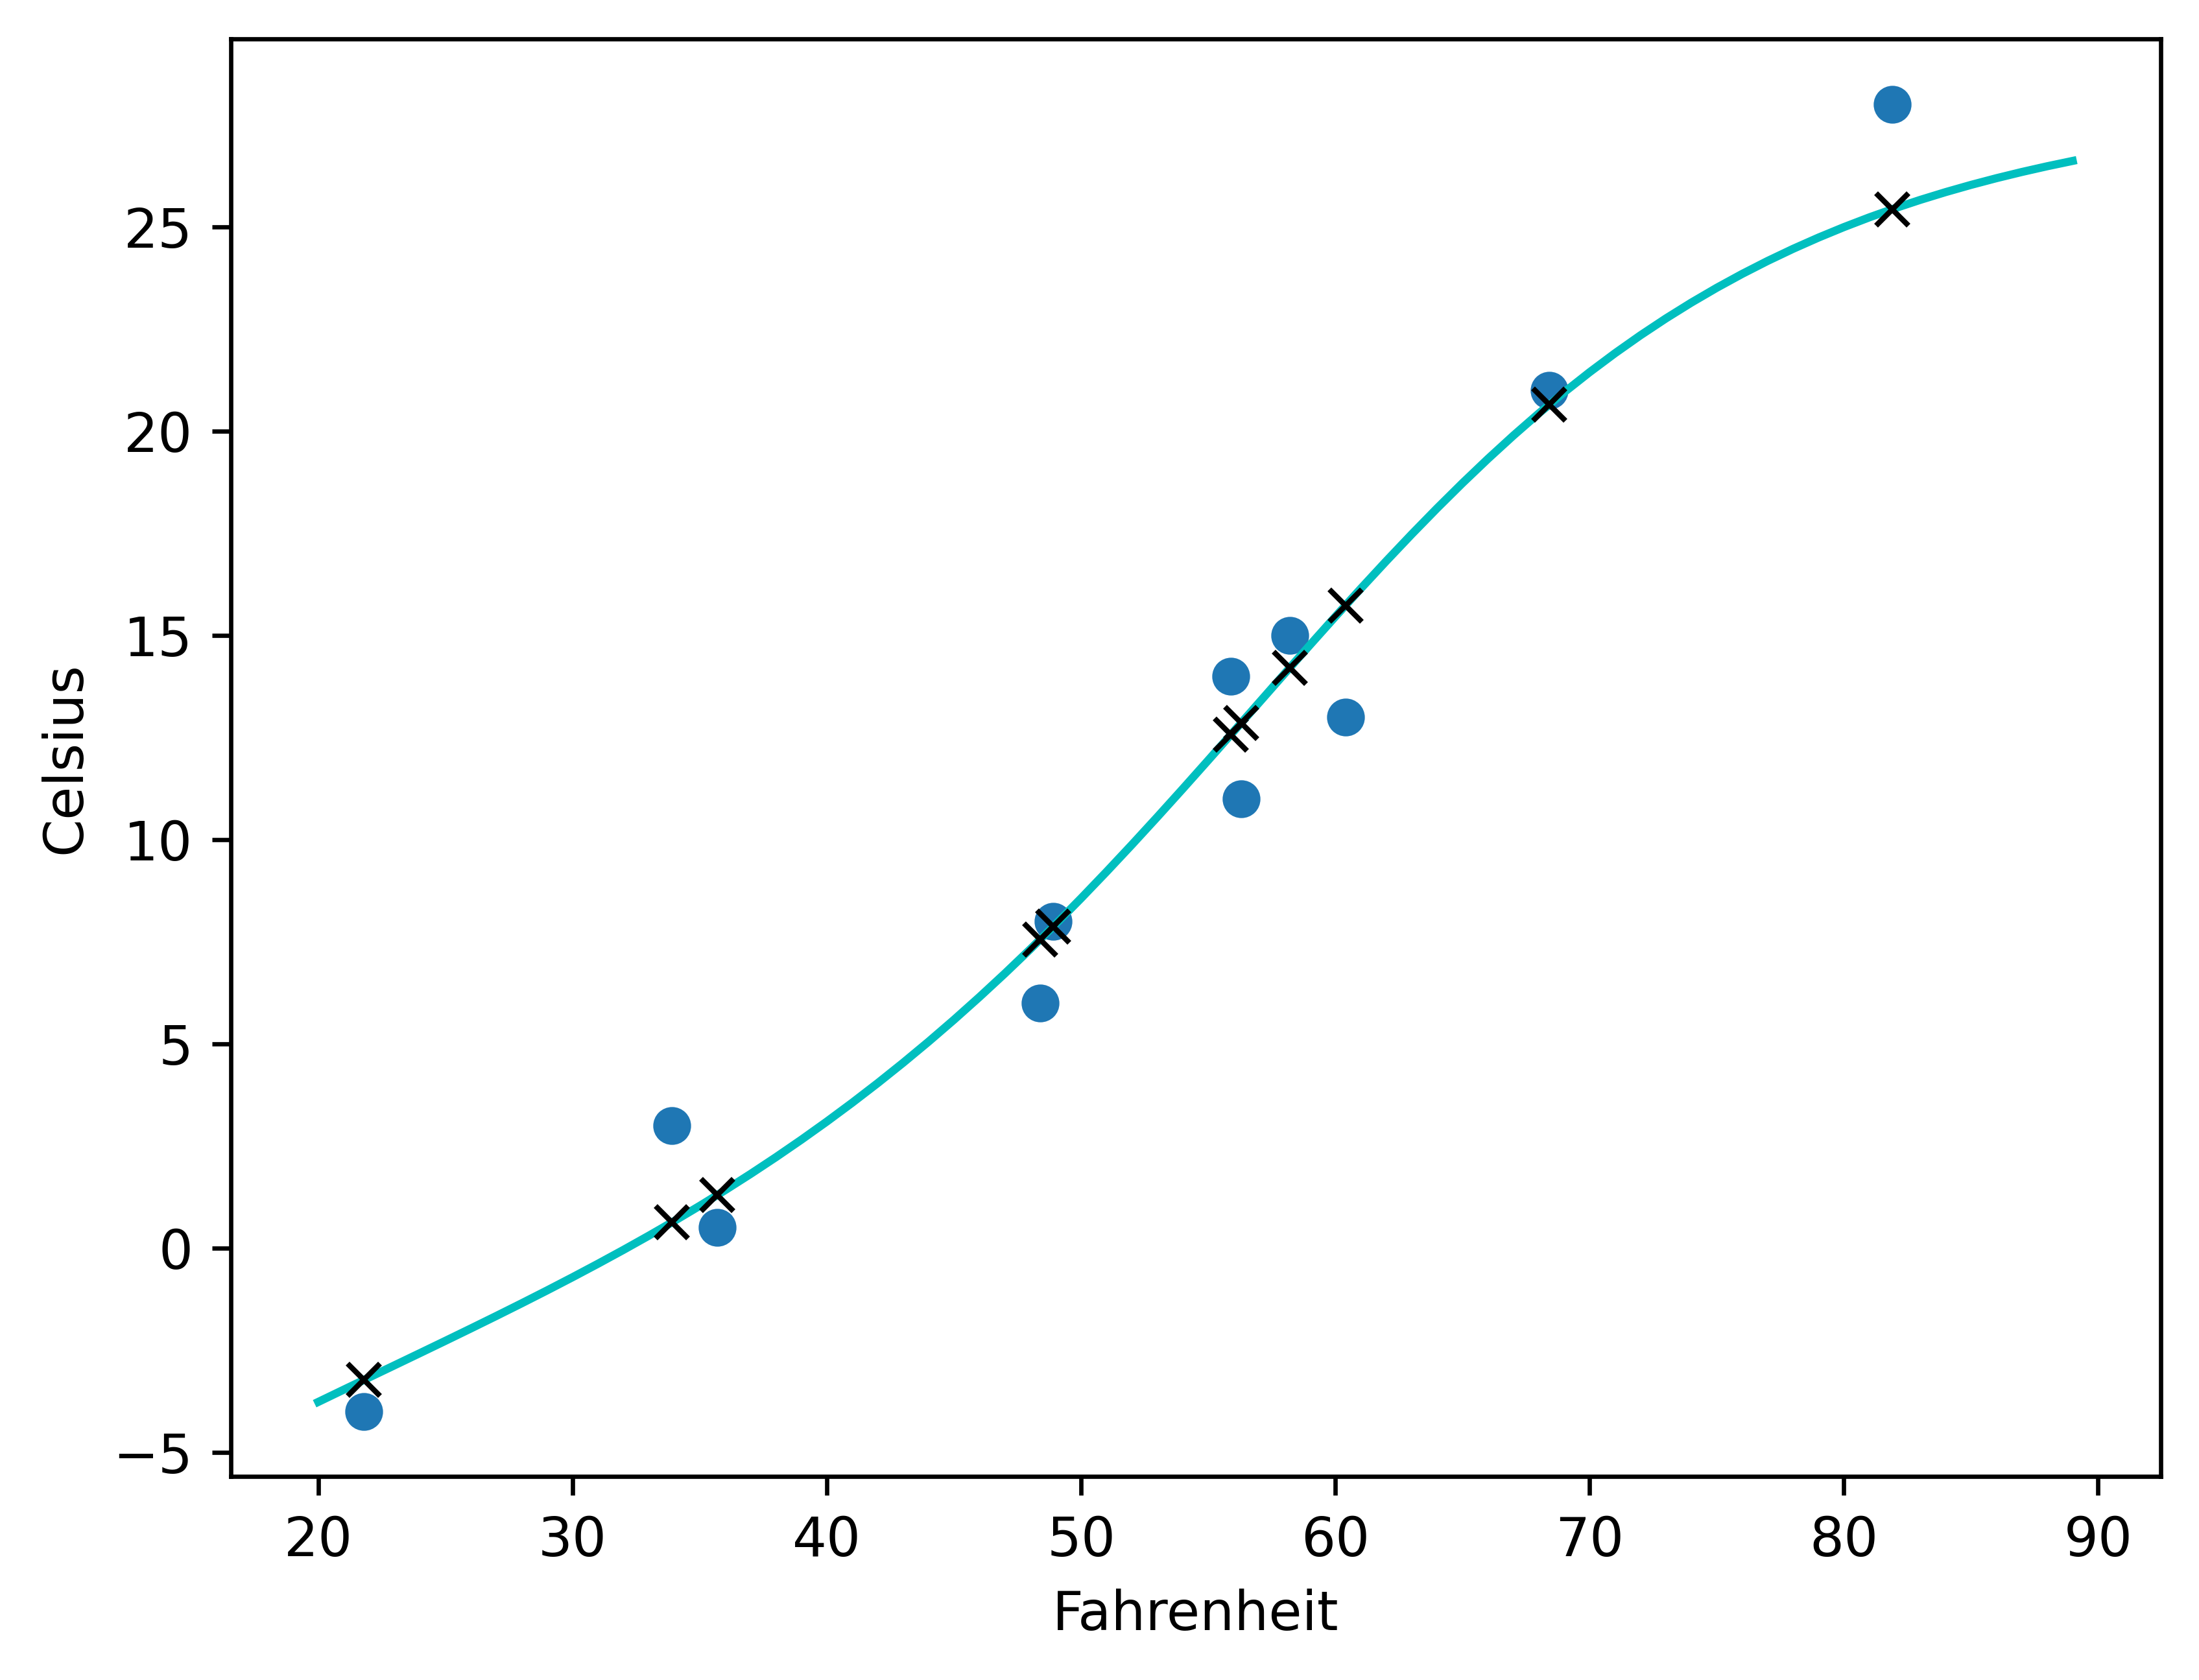

In [27]:
# Visualize
from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)

fig = plt.figure(dpi=600)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), 'kx')

In [28]:
seq_model(0.1 * t_u).detach().numpy()

array([[ 1.2951133 ],
       [12.570075  ],
       [14.19529   ],
       [25.427094  ],
       [12.852596  ],
       [ 7.8630104 ],
       [ 0.62095046],
       [-3.2323635 ],
       [ 7.55451   ],
       [15.729011  ],
       [20.638065  ]], dtype=float32)

The neural network fits the tiny training set very closely, but this is overfitting. The original temperature-conversion problem is basically linear, so a more flexible nonlinear model can learn unnecessary wiggles instead of the simple relationship.